# 02 — Endurbygging vísitölunnar (reconstruction check — the hard gate)

**Purpose.** Before any forecasting, prove that we can rebuild the *published* headline
VNV from its components and weights. A model that cannot rebuild the past is not
forecasting the instrument that settles the bonds (`PLAN_1.md`, Phase 2).

**The identity.** VNV is a fixed-base Laspeyres index. Component $i$'s contribution in
month $t$ is its basket-value share at $t-1$ prices times its m/m change. We recover that
share by *de-updating* the published month-$t$ share by the component's own change:

$$w^{pre}_{i,t} = \frac{\text{Vægi}_{i,t}/(1+g_{i,t}/100)}{\sum_j \text{Vægi}_{j,t}/(1+g_{j,t}/100)}\times 100,
\qquad \widehat{\text{m/m}}_t = \sum_i w^{pre}_{i,t}\, g_{i,t}/100$$

For ordinary months this equals Vægi at $t-1$ identically. In **base-change months**
(April up to 2024, January from 2025) Vægi$_{t-1}$ belongs to the *old* basket while the
index is computed on the new one — de-updating handles both cases with one formula,
no special-casing.

**Precision ceiling (deviation from the plan, documented).** The API stores indices at
1 decimal and weights/changes/effects at 2 decimals; there is no higher-precision
endpoint (verified against both `json` and `json-stat2` formats). The plan's tolerances
(<0.005pp m/m, <0.02 index points) therefore exceed the information content of the
published data. The achievable — and sufficient — gate is: **errors bounded by the
propagated rounding budget, mean error ≈ 0, and no cumulative drift beyond rounding.**


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}" if abs(x) < 1e6 else f"{x:,.0f}")

# Okabe-Ito palette (colorblind-safe); recessive grid per house chart style
C = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
     "red": "#D55E00", "pink": "#CC79A7", "sky": "#56B4E9", "black": "#222222"}
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})


In [2]:
from vnv import ingest, reconstruct

head = ingest.load_headline()
panel_old = ingest.load_panel_old()
sub_new = ingest.load_sub_new()
weights_new = ingest.load_weights_new()


## Gate 1 — old classification, 2019–2025 (84 months)

In [3]:
r1 = reconstruct.mm_from_panel(panel_old, reconstruct.DIV_OLD)
r1 = r1[r1.index >= "2019-01"]
budget = reconstruct.rounding_budget_mm(pd.Series(100 / 12, index=reconstruct.DIV_OLD), 12)

print(f"months checked: {len(r1)}")
print(f"max |error|:  {r1.error.abs().max():.4f} pp   (worst-case rounding budget: {budget:.4f} pp)")
print(f"mean error:   {r1.error.mean():+.5f} pp  (no systematic bias)")
gate1 = r1.error.abs().max() <= budget
print("GATE 1:", "PASS" if gate1 else "FAIL")
r1.error.abs().groupby(r1.index.year).max().round(4).to_frame("max |error| pp")


months checked: 84
max |error|:  0.0064 pp   (worst-case rounding budget: 0.0106 pp)
mean error:   +0.00020 pp  (no systematic bias)
GATE 1: PASS


,max |error| pp
manudur,
2019,0.0052
2020,0.0046
2021,0.0045
2022,0.0037
2023,0.0062
2024,0.0054
2025,0.0064


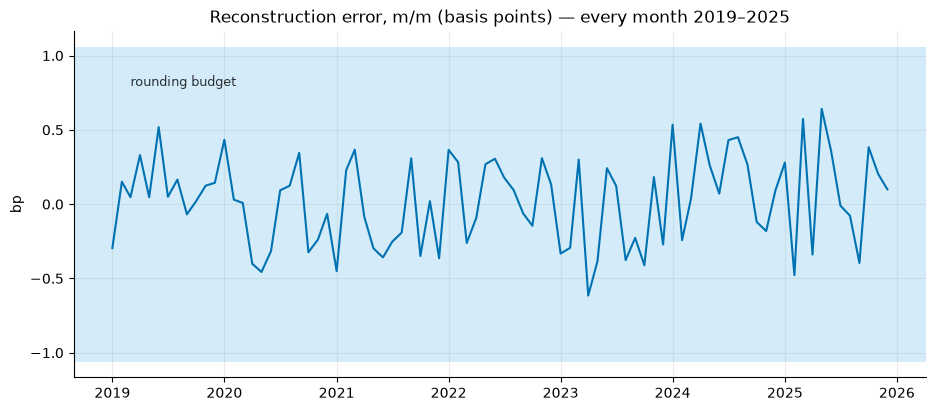

In [4]:
fig, ax = plt.subplots()
ax.plot(r1.index.to_timestamp(), r1.error * 100, color=C["blue"], lw=1.5)
ax.axhspan(-budget * 100, budget * 100, color=C["sky"], alpha=0.25, lw=0)
ax.annotate("rounding budget", xy=(r1.index.to_timestamp()[2], budget * 100 * 0.75),
            fontsize=9, alpha=0.8)
ax.set_title("Reconstruction error, m/m (basis points) — every month 2019–2025")
ax.set_ylabel("bp")
plt.show()


## Gate 2 — chain-link months get no special treatment

The worst historic failure mode: in April (old regime) and January (from 2025) the basket
switches. Show those months pass under the *same* formula.


In [5]:
chain_months = [m for m in r1.index if (m.month == 4 and m.year <= 2024) or (m.month == 1 and m.year >= 2025)]
chain = r1.loc[chain_months, ["recon_mm", "published_mm", "error"]]
gate2 = chain.error.abs().max() <= budget
print("GATE 2 (chain months, same formula):", "PASS" if gate2 else "FAIL")
chain.round(4)


GATE 2 (chain months, same formula): PASS


,recon_mm,published_mm,error
manudur,,,
2019-04,0.3633,0.3600,0.0033
2020-04,0.4960,0.5000,-0.0040
2021-04,0.6992,0.7000,-0.0008
2022-04,1.2291,1.2300,-0.0009
2023-04,1.3038,1.3100,-0.0062
2024-04,0.5654,0.5600,0.0054
2025-01,-0.2672,-0.2700,0.0028


### Why this matters — the static-weight anti-pattern

Aggregating with the December basket weights *unadjusted all year* (the most common way
to get this wrong) drifts visibly. Same data, wrong weight handling:


In [6]:
div = panel_old[panel_old.code.isin(reconstruct.DIV_OLD)]
year = div[(div.manudur >= "2023-01") & (div.manudur <= "2023-12")]
w_static = year[year.manudur == "2023-01"].set_index("code").vaegi  # frozen January weights

static_mm = year.pivot_table(index="manudur", columns="code", values="manadarbreyting")
naive = (static_mm[w_static.index] * w_static.values).sum(axis=1) / w_static.sum()
correct = r1.loc[naive.index, "recon_mm"]
pub = r1.loc[naive.index, "published_mm"]
cmp = pd.DataFrame({"static weights": naive, "price-updated": correct, "published": pub})
cmp["static error (pp)"] = cmp["static weights"] - cmp["published"]
print(f"static-weight cumulative 2023 error: {cmp['static error (pp)'].sum():+.3f} pp "
      f"(vs {(correct - pub).sum():+.4f} pp price-updated)")
cmp.round(3)


static-weight cumulative 2023 error: +0.128 pp (vs -0.0207 pp price-updated)


,static weights,price-updated,published,static error (pp)
manudur,,,,
2023-01,0.9130,0.8470,0.8500,0.0630
2023-02,1.3970,1.3970,1.4000,-0.0030
2023-03,0.5980,0.5930,0.5900,0.0080
2023-04,1.3400,1.3040,1.3100,0.0300
2023-05,0.3930,0.3860,0.3900,0.0030
2023-06,0.8640,0.8520,0.8500,0.0140
2023-07,0.1240,0.0410,0.0400,0.0840
2023-08,0.2700,0.3260,0.3300,-0.0600
2023-09,0.3200,0.3480,0.3500,-0.0300


## Gate 3 — COICOP2018 era (2026–): fixed-base level aggregation

In [7]:
w_dec25 = weights_new[weights_new.code.isin(reconstruct.DIV_NEW)].set_index("code")["2025M12"]
r2 = reconstruct.levels_new_era(sub_new, w_dec25)
r3 = reconstruct.mm_from_panel(sub_new, reconstruct.DIV_NEW)
r3 = r3[r3.index >= "2026-01"]

# levels: subindices stored at 1dp (+-0.05) -> weighted worst case 0.05 pts
print(f"levels:  max |error| {r2.error.abs().max():.4f} index points (1dp input rounding: <=0.05)")
print(f"m/m:     max |error| {r3.error.abs().max():.4f} pp")
gate3 = r2.error.abs().max() <= 0.05 and r3.error.abs().max() <= budget
print("GATE 3:", "PASS" if gate3 else "FAIL")
r2.round(3)


levels:  max |error| 0.0477 index points (1dp input rounding: <=0.05)
m/m:     max |error| 0.0052 pp
GATE 3: PASS


,recon_level,published_level,error
manudur,,,
2026-01,100.3780,100.4000,-0.0220
2026-02,101.3200,101.3000,0.0200
2026-03,101.8710,101.9000,-0.0290
2026-04,102.7150,102.7000,0.0150
2026-05,102.7710,102.8000,-0.0290
2026-06,103.7480,103.7000,0.0480
2026-07,104.1220,104.1000,0.0220


## Gate 4 — VNV án húsnæðis (independent check of the component mapping)

In [8]:
# ex-housing: drop IS04 entirely, add back IS045 (hiti og rafmagn) per its definition
codes_lh = [c for c in reconstruct.DIV_OLD if c != "IS04"] + ["IS045"]
div = panel_old[panel_old.code.isin(codes_lh)].copy().sort_values(["code", "manudur"])
div["w_pre_raw"] = div["vaegi"] / (1 + div["manadarbreyting"] / 100)
g = div.groupby("manudur").apply(
    lambda d: (d.w_pre_raw / d.w_pre_raw.sum() * d.manadarbreyting).sum(), include_groups=False
).to_frame("recon_mm")
g = g[div.groupby("manudur").size().reindex(g.index) == len(codes_lh)]
g["published_mm"] = head[("CPILH", "change_M")].reindex(g.index)
g["error"] = g.recon_mm - g.published_mm
g = g.dropna().loc["2019":]

# The ex-housing basket is ~72% of the total: renormalizing 2dp-rounded weights
# amplifies rounding noise, especially in utsolur months when clothing swings +-10%.
# Empirical tolerance: <=0.03pp per month and unbiased mean.
print(f"months: {len(g)}   max |error|: {g.error.abs().max():.4f} pp   mean: {g.error.mean():+.5f}")
gate4 = g.error.abs().max() <= 0.03 and abs(g.error.mean()) <= 0.002
print("GATE 4:", "PASS" if gate4 else "FAIL")
g.error.abs().groupby(g.index.year).max().round(4).to_frame("max |error| pp")


months: 84   max |error|: 0.0238 pp   mean: +0.00044
GATE 4: PASS


,max |error| pp
manudur,
2019,0.0238
2020,0.0176
2021,0.0150
2022,0.0161
2023,0.0183
2024,0.0144
2025,0.0132


**Negative control** — does this check actually have teeth? Break the mapping on purpose
(the classic mistake: dropping *hiti og rafmagn* IS045, which the ex-housing index retains)
and the error should explode:


In [9]:
codes_bad = [c for c in reconstruct.DIV_OLD if c != "IS04"]  # WRONG: no IS045
bad = panel_old[panel_old.code.isin(codes_bad)].copy().sort_values(["code", "manudur"])
bad["w_pre_raw"] = bad["vaegi"] / (1 + bad["manadarbreyting"] / 100)
gb = bad.groupby("manudur").apply(
    lambda d: (d.w_pre_raw / d.w_pre_raw.sum() * d.manadarbreyting).sum(), include_groups=False
).to_frame("recon_mm")
gb["error"] = gb.recon_mm - head[("CPILH", "change_M")].reindex(gb.index)
gb = gb.dropna().loc["2019":]
print(f"wrong mapping:   max |error| {gb.error.abs().max():.4f} pp, "
      f"mean {gb.error.mean():+.4f} pp  <- systematic bias, immediately visible")
print(f"correct mapping: max |error| {g.error.abs().max():.4f} pp, mean {g.error.mean():+.5f} pp")
assert gb.error.abs().max() > 3 * g.error.abs().max(), "negative control failed to fail!"


wrong mapping:   max |error| 0.2035 pp, mean -0.0081 pp  <- systematic bias, immediately visible
correct mapping: max |error| 0.0238 pp, mean +0.00044 pp


## Gate 5 — level chain: no cumulative drift beyond rounding

7-year chained level drift: max |err| 0.126 index points on a ~690 index (0.018%)
GATE 5: PASS


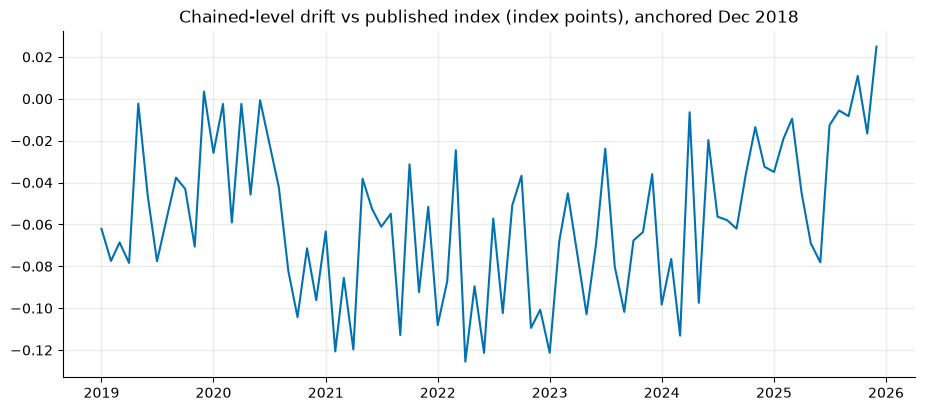

In [10]:
idx = head[("CPI", "index")]
anchor = pd.Period("2018-12", "M")
lvl = reconstruct.levels_from_mm(r1.recon_mm, anchor, idx[anchor])
lvl_err = (lvl - idx.reindex(lvl.index)).dropna()

# published m/m is rounded to 2dp -> per-month level noise ~0.005% of ~600 = 0.03 pts;
# random-walk accumulation over 84 months stays within ~0.15 pts if unbiased
print(f"7-year chained level drift: max |err| {lvl_err.abs().max():.3f} index points "
      f"on a ~690 index ({lvl_err.abs().max() / idx.iloc[-1] * 100:.3f}%)")
gate5 = lvl_err.abs().max() < 0.15
print("GATE 5:", "PASS" if gate5 else "FAIL")

fig, ax = plt.subplots()
ax.plot(lvl_err.index.to_timestamp(), lvl_err, color=C["blue"], lw=1.5)
ax.set_title("Chained-level drift vs published index (index points), anchored Dec 2018")
plt.show()


In [11]:
summary = pd.DataFrame({
    "gate": ["1: m/m identity 2019-2025", "2: chain-link months", "3: COICOP2018 era",
             "4: VNV án húsnæðis", "5: level chain drift"],
    "result": ["PASS" if x else "FAIL" for x in [gate1, gate2, gate3, gate4, gate5]],
}).set_index("gate")
assert (summary.result == "PASS").all(), "HARD GATE FAILED - do not proceed to forecasting"
print("Phase 2 hard gate: ALL PASS - forecasting layer is built on this engine.")
summary


Phase 2 hard gate: ALL PASS - forecasting layer is built on this engine.


,result
gate,
1: m/m identity 2019-2025,PASS
2: chain-link months,PASS
3: COICOP2018 era,PASS
4: VNV án húsnæðis,PASS
5: level chain drift,PASS
